In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# import tensorflow_model_optimization as tfmot
import tensorflow.lite as tflite

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [69]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import tensorflow as tf

print("GPUs:", tf.config.list_physical_devices("GPU"))
print("CPUs:", tf.config.list_physical_devices("CPU"))

GPUs: []
CPUs: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [70]:
DATASET_PATH = "/mnt/d/waste-classification-system-II/resized_dataset"

IMG_SIZE = (64, 64)
BATCH_SIZE = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 8407 files belonging to 9 classes.
Using 6726 files for training.
Found 8407 files belonging to 9 classes.
Using 1681 files for validation.


In [71]:
class_names = train_ds.class_names
num_classes = len(class_names)

print(class_names)
print("Number of classes:", num_classes)

['cardboard', 'e-waste', 'glass', 'metal', 'organic', 'paper', 'plastic', 'textile', 'trash']
Number of classes: 9


In [72]:
val_size = int(0.5 * len(val_test_ds))

val_ds = val_test_ds.take(val_size)
test_ds = val_test_ds.skip(val_size)

In [73]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

In [74]:
data_aug = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

In [75]:
tiny_model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(64, 64, 3)),

    tf.keras.layers.Conv2D(24, 3, activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(48, 3, activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(96, 3, activation="relu", padding="same"),
    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(num_classes, activation="softmax")
])

tiny_model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

tiny_model.summary()

Model: "sequential_13"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_8 (Rescaling)     (None, 64, 64, 3)         0         
                                                                 
 conv2d_24 (Conv2D)          (None, 64, 64, 24)        672       
                                                                 
 max_pooling2d_16 (MaxPoolin  (None, 32, 32, 24)       0         
 g2D)                                                            
                                                                 
 conv2d_25 (Conv2D)          (None, 32, 32, 48)        10416     
                                                                 
 max_pooling2d_17 (MaxPoolin  (None, 16, 16, 48)       0         
 g2D)                                                            
                                                                 
 conv2d_26 (Conv2D)          (None, 16, 16, 96)      

In [76]:
history = tiny_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs= 50
)

Epoch 1/50


2026-04-26 19:54:16.761218: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [6726]
	 [[{{node Placeholder/_0}}]]
2026-04-26 19:54:16.761536: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [6726]
	 [[{{node Placeholder/_0}}]]


211/211 [==============================] - ETA: 0s - loss: 2.0627 - accuracy: 0.2120

2026-04-26 19:54:31.341219: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [1681]
	 [[{{node Placeholder/_4}}]]
2026-04-26 19:54:31.341487: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [1681]
	 [[{{node Placeholder/_0}}]]


211/211 [==============================] - 15s 59ms/step - loss: 2.0627 - accuracy: 0.2120 - val_loss: 1.9443 - val_accuracy: 0.2668
Epoch 2/50
211/211 [==============================] - 13s 63ms/step - loss: 1.8863 - accuracy: 0.3072 - val_loss: 1.8484 - val_accuracy: 0.3317
Epoch 3/50
211/211 [==============================] - 11s 52ms/step - loss: 1.8215 - accuracy: 0.3396 - val_loss: 1.7945 - val_accuracy: 0.3413
Epoch 4/50
211/211 [==============================] - 11s 52ms/step - loss: 1.7467 - accuracy: 0.3686 - val_loss: 1.8493 - val_accuracy: 0.3245
Epoch 5/50
211/211 [==============================] - 13s 60ms/step - loss: 1.7130 - accuracy: 0.3785 - val_loss: 1.7293 - val_accuracy: 0.3546
Epoch 6/50
211/211 [==============================] - 11s 52ms/step - loss: 1.6695 - accuracy: 0.3977 - val_loss: 1.6458 - val_accuracy: 0.4135
Epoch 7/50
211/211 [==============================] - 11s 52ms/step - loss: 1.6291 - accuracy: 0.4126 - val_loss: 1.6198 - val_accuracy: 0.4303
Epo

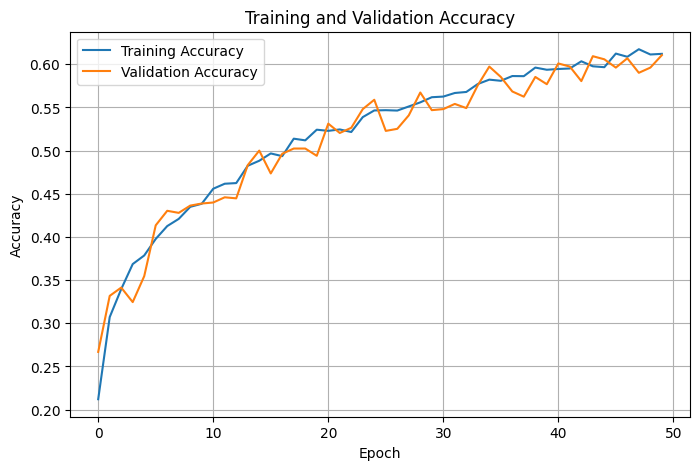

In [77]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [78]:
test_loss, test_acc = tiny_model.evaluate(test_ds)

print("Test Accuracy:", test_acc)

2026-04-26 20:08:50.151159: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [1681]
	 [[{{node Placeholder/_0}}]]
2026-04-26 20:08:50.151949: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [1681]
	 [[{{node Placeholder/_0}}]]


27/27 [==============================] - 1s 37ms/step - loss: 1.2100 - accuracy: 0.5948
Test Accuracy: 0.5948174595832825


In [79]:
tiny_model.save("/mnt/d/waste-classification-system-II/notebooks/models/tiny_model_final.keras")

### Conevrt To Int8

In [80]:
def representative_data_gen():
    for images, _ in train_ds.take(100):
        yield [tf.cast(images, tf.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(tiny_model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen

converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.uint8
converter.inference_output_type = tf.uint8

tflite_model = converter.convert()

2026-04-26 20:09:34.624742: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'inputs' with dtype float and shape [?,96]
	 [[{{node inputs}}]]
2026-04-26 20:09:34.956906: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'inputs' with dtype float and shape [?,96]
	 [[{{node inputs}}]]


INFO:tensorflow:Assets written to: /tmp/tmpqrfktovf/assets


INFO:tensorflow:Assets written to: /tmp/tmpqrfktovf/assets
/home/krishna/miniconda3/envs/tf_gpu/lib/python3.10/site-packages/tensorflow/lite/python/convert.py:789: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn("Statistics for quantized inputs were expected, but not "
2026-04-26 20:09:35.805514: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
2026-04-26 20:09:35.805577: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-04-26 20:09:35.808083: I tensorflow/cc/saved_model/reader.cc:45] Reading SavedModel from: /tmp/tmpqrfktovf
2026-04-26 20:09:35.810179: I tensorflow/cc/saved_model/reader.cc:89] Reading meta graph with tags { serve }
2026-04-26 20:09:35.810239: I tensorflow/cc/saved_model/reader.cc:130] Reading SavedModel debug info (if present) from: /tmp/tmpqrfktovf
2026-04-26 20:09:35.819465: I tensorflow/compile

In [81]:
import os

path = "/mnt/d/waste-classification-system-II/notebooks/models/tiny_model_int8.tflite"

with open(path, "wb") as f:
    f.write(tflite_model)

size_kb = os.path.getsize(path) / 1024
print("Model size KB:", size_kb)

Model size KB: 61.2890625


In [82]:
test_loss, test_acc = tiny_model.evaluate(test_ds)
print("Final Test Accuracy:", test_acc)
print("Final Test Loss:", test_loss)

27/27 [==============================] - 0s 10ms/step - loss: 1.2100 - accuracy: 0.5948
Final Test Accuracy: 0.5948174595832825
Final Test Loss: 1.2100046873092651


In [83]:
with open("/mnt/d/waste-classification-system-II/notebooks/models/labels.txt", "w") as f:
    for label in class_names:
        f.write(label + "\n")

In [84]:
with open("/mnt/d/waste-classification-system-II/notebooks/models/labels.txt", "w") as f:
    for label in class_names:
        f.write(label + "\n")